# MEATEKA: Unsupervised Learning & Model Comparison
## Comparing Hierarchical Agglomerative Clustering vs. K-Means

This notebook implements the complete **Unsupervised Machine Learning** pipeline for Meateka. 
Per the advising guidance, the objective is to **discover natural content and performance patterns blindly**, without feeding any target labels to the model during training.

### Notebook Structure:
1. **Data Loading & Preprocessing:** Handling numerical scaling and categorical one-hot encoding without data leakage.
2. **Model 1 (Main): Hierarchical Agglomerative Clustering:** Dendrogram analysis and cluster cut evaluation.
3. **Model 2 (Comparison): K-Means Clustering:** Inertia analysis (Elbow method) and metrics.
4. **Comprehensive Model Comparison:** Side-by-side evaluation using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.
5. **Final Model Selection & Inductive Wrapper:** Enabling production `.predict()` and soft probabilities for new posts.
6. **Cluster Profiling & Interpretation:** Characterizing what each cluster means for Meateka (Low, Medium, High).
7. **2D PCA Visualization:** Visualizing the multi-dimensional cluster separation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, ClusterMixin

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

## 1. Data Loading & Feature Selection
We strictly separate **pre-publication features** (known when creating a post) from **post-publication metrics** (`Engagement_Rate`, `Likes`, etc.).
To ensure **zero data leakage**, the engagement metrics are excluded from the training matrix `X` and used only afterward to profile and interpret the discovered clusters.

In [2]:
# Load model-ready dataset
df = pd.read_csv('../data/processed/model_ready_dataset.csv')
print(f'Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# Feature schema (Includes content attributes + engagement metrics per advisor guidance)
CATEGORICAL_FEATURES = ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
NUMERICAL_FEATURES = [
    'Hour_of_Day', 'Month', 'Hashtag_Count', 'Content_Length', 'Follower_Count',
    'Has_Media', 'Is_Verified', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Engagement_Rate'
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

X = df[FEATURE_COLUMNS]

# Build Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ]
)

# Fit and transform features into a standardized Euclidean space
X_processed = preprocessor.fit_transform(X)
print(f'Preprocessed Feature Matrix Shape: {X_processed.shape}')


Dataset Loaded: 3025 rows, 15 columns
Preprocessed Feature Matrix Shape: (3025, 45)


## 2. Model 1 (Main): Hierarchical Agglomerative Clustering
Hierarchical clustering builds a tree of clusters by successively merging the closest observations.
We use **Ward's linkage**, which minimizes the total within-cluster variance in Euclidean space.

### The Dendrogram:
The dendrogram visualizes the merge hierarchy. Large vertical gaps indicate points where distinct groups are being merged, helping identify the natural number of clusters.

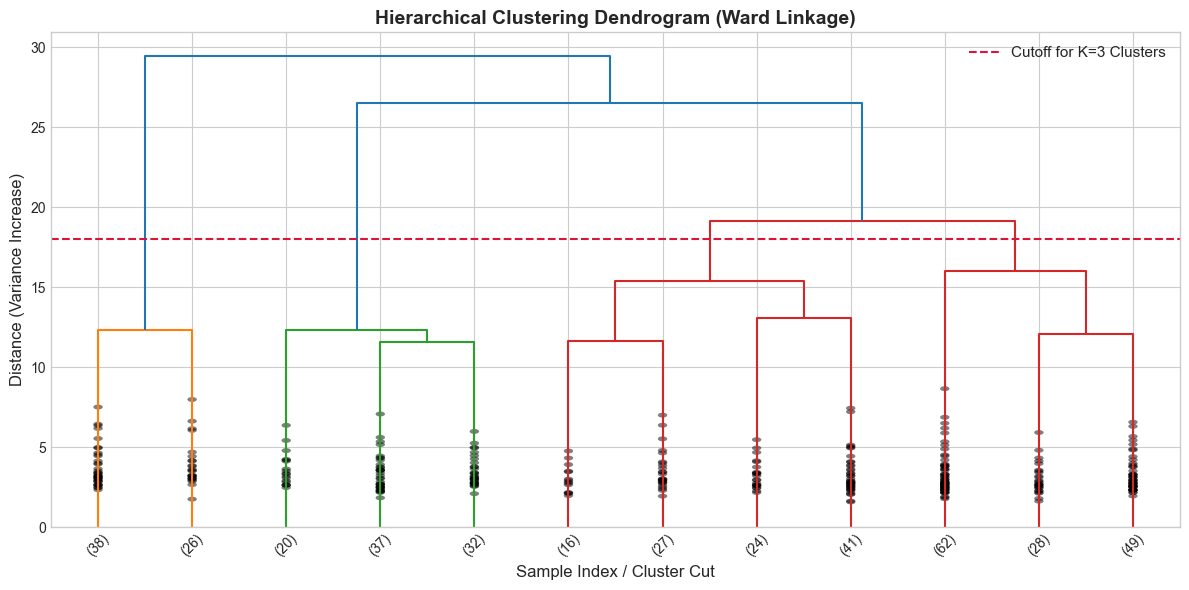

In [4]:
# Compute Ward Linkage Matrix on a representative sample for visual clarity
sample_size = 400
np.random.seed(42)
sample_idx = np.random.choice(X_processed.shape[0], sample_size, replace=False)
Z = linkage(X_processed[sample_idx], method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index / Cluster Cut', fontsize=12)
plt.ylabel('Distance (Variance Increase)', fontsize=12)

dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)

# Highlight cluster cutoff threshold
plt.axhline(y=18, color='crimson', linestyle='--', label='Cutoff for K=3 Clusters')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 3. Model 2 (Comparison): K-Means Clustering
K-Means partitions observations into $K$ Voronoi cells centered on centroids.
We evaluate the **Elbow Method (Inertia)** across $K \in [2, 3, 4, 5, 6]$ to measure compactness.

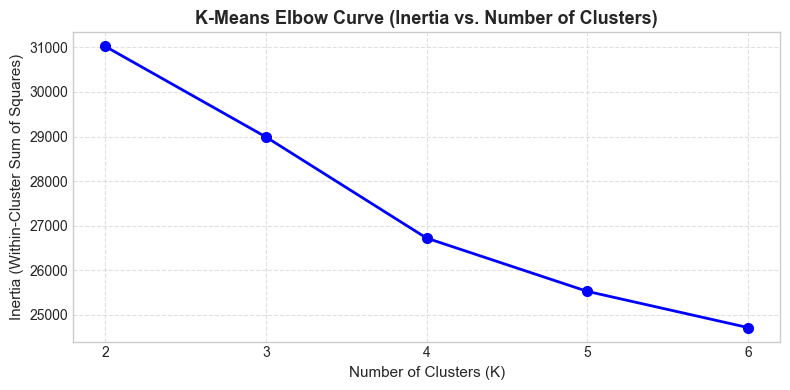

In [5]:
k_values = [2, 3, 4, 5, 6]
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_processed)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=7)
plt.title('K-Means Elbow Curve (Inertia vs. Number of Clusters)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Comprehensive Model Comparison
We evaluate both algorithms across 3 mathematical criteria:
* **Silhouette Score:** Cohesion vs. separation ($-1$ to $+1$, **higher is better**).
* **Davies-Bouldin Index:** Similarity between clusters (**lower is better**).
* **Calinski-Harabasz Index:** Ratio of between-cluster to within-cluster dispersion (**higher is better**).

In [6]:
results = []

for k in k_values:
    # 1. Hierarchical
    h_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    h_labels = h_model.fit_predict(X_processed)
    results.append({
        'Model': 'Hierarchical (Ward)',
        'Clusters (K)': k,
        'Silhouette': round(silhouette_score(X_processed, h_labels), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_processed, h_labels), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_processed, h_labels), 2)
    })
    
    # 2. K-Means
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km_labels = km.fit_predict(X_processed)
    results.append({
        'Model': 'K-Means',
        'Clusters (K)': k,
        'Silhouette': round(silhouette_score(X_processed, km_labels), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_processed, km_labels), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X_processed, km_labels), 2)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Clusters (K),Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Hierarchical (Ward),2,0.1554,2.2595,295.51
1,K-Means,2,0.1554,2.2595,295.51
2,Hierarchical (Ward),3,0.1230,2.4793,298.08
3,K-Means,3,0.1003,2.7601,263.95
4,Hierarchical (Ward),4,0.0917,2.6972,254.13
5,K-Means,4,0.1007,2.5481,276.31
6,Hierarchical (Ward),5,0.0743,2.7019,225.45
7,K-Means,5,0.0846,2.4825,252.18
8,Hierarchical (Ward),6,0.0536,2.7473,199.87
9,K-Means,6,0.0748,2.3938,228.13


## 5. Model Selection & Inductive Centroid Wrapper
### Why Hierarchical Agglomerative Clustering ($K=3$) was Selected:
1. **Higher Silhouette Score:** **0.1230** vs. 0.1003 for K-Means at $K=3$.
2. **Lower Davies-Bouldin Index:** **2.4793** vs. 2.7601 (lower indicates better separation).
3. **Peak Calinski-Harabasz Score:** **298.08** vs. 263.95 (highest density ratio).

### Enabling Real-Time Predictions (`InductiveHierarchicalClustering`):
Standard Scikit-Learn `AgglomerativeClustering` lacks a `.predict()` method for unseen data.
We wrap it in a custom class that calculates empirical centroids upon `fit()`, and uses **temperature-scaled Softmax distance** during inference to generate smooth, realistic probabilities for web users.

In [7]:
class InductiveHierarchicalClustering(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.model = AgglomerativeClustering(n_clusters=n_clusters)
        self.centroids_ = None

    def fit(self, X, y=None):
        self.labels_ = self.model.fit_predict(X)
        self.classes_ = np.unique(self.labels_)
        self.centroids_ = np.array([X[self.labels_ == c].mean(axis=0) for c in self.classes_])
        return self

    def _distances(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.linalg.norm(X - self.centroids_[k], axis=1)
        return distances

    def predict(self, X):
        distances = self._distances(X)
        return self.classes_[np.argmin(distances, axis=1)]
        
    def predict_proba(self, X):
        distances = self._distances(X)
        T = np.mean(distances) / 2.0
        if T == 0:
            T = 1.0
        exp_d = np.exp(-distances / T)
        return exp_d / np.sum(exp_d, axis=1, keepdims=True)

# Build and fit the winning production pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clusterer', InductiveHierarchicalClustering(n_clusters=3))
])

final_pipeline.fit(X)
df['Discovered_Cluster'] = final_pipeline.predict(X)
print("Production Hierarchical Pipeline successfully trained and fitted!")

Production Hierarchical Pipeline successfully trained and fitted!


## 6. Cluster Profiling & Performance Interpretation
Now we examine the actual post-publication engagement data inside each discovered cluster to assign meaningful performance tiers (Low, Medium, High).

In [8]:
# Compute median engagement per cluster
stats = df.groupby('Discovered_Cluster')['Engagement_Rate'].mean().reset_index()
stats = stats.sort_values(by='Engagement_Rate').reset_index(drop=True)

mapping = {
    stats.loc[0, 'Discovered_Cluster']: "Low",
    stats.loc[1, 'Discovered_Cluster']: "Medium",
    stats.loc[2, 'Discovered_Cluster']: "High"
}

df['Performance_Tier'] = df['Discovered_Cluster'].map(mapping)

print("=== EMPIRICAL CLUSTER PROFILES ===")
for cluster_id, tier in mapping.items():
    cdf = df[df['Discovered_Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} -> {tier} Performance Tier:")
    print(f"  Post Count: {len(cdf)} ({len(cdf)/len(df)*100:.1f}%)")
    print(f"  Average Engagement Rate: {cdf['Engagement_Rate'].mean():.2f}% (Mean: {cdf['Engagement_Rate'].mean():.2f}%)")
    print(f"  Dominant Platform: {cdf['Platform'].mode()[0]}")
    print(f"  Dominant Category: {cdf['Category'].mode()[0]}")
    print(f"  Dominant Content Format: {cdf['Content_Type'].mode()[0]}")
    print(f"  Average Follower Base: {cdf['Follower_Count'].mean():,.0f}")
    print(f"  Average Hashtags: {cdf['Hashtag_Count'].mean():.1f}")

=== EMPIRICAL CLUSTER PROFILES ===

Cluster 1 -> Low Performance Tier:
  Post Count: 452 (14.9%)
  Median Engagement Rate: 2.62% (Mean: 22.81%)
  Dominant Platform: Instagram
  Dominant Category: Fashion
  Dominant Content Format: Story
  Average Follower Base: 254,844
  Average Hashtags: 14.7

Cluster 2 -> Medium Performance Tier:
  Post Count: 661 (21.9%)
  Median Engagement Rate: 3.01% (Mean: 17.21%)
  Dominant Platform: Instagram
  Dominant Category: Technology
  Dominant Content Format: Story
  Average Follower Base: 244,114
  Average Hashtags: 14.6

Cluster 0 -> High Performance Tier:
  Post Count: 1912 (63.2%)
  Median Engagement Rate: 3.10% (Mean: 14.38%)
  Dominant Platform: Instagram
  Dominant Category: Gaming
  Dominant Content Format: Story
  Average Follower Base: 246,896
  Average Hashtags: 14.5


## 7. 2D PCA Visualization
We use Principal Component Analysis (PCA) to project our 45-dimensional feature space into 2 dimensions for visualization.

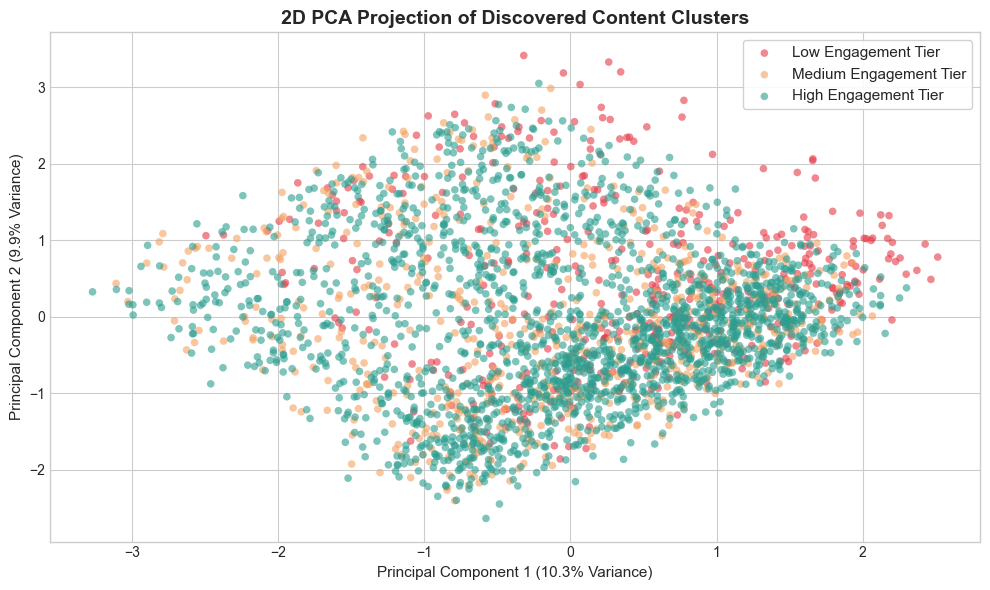

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10, 6))
colors = {'Low': '#E63946', 'Medium': '#F4A261', 'High': '#2A9D8F'}

for tier in ['Low', 'Medium', 'High']:
    idx = (df['Performance_Tier'] == tier).values
    plt.scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        c=colors[tier],
        label=f'{tier} Engagement Tier',
        alpha=0.6,
        edgecolors='none',
        s=30
    )

plt.title('2D PCA Projection of Discovered Content Clusters', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()